<a href="https://colab.research.google.com/github/lenmecc/miniature-enigma/blob/main/Proyecto_integrador_1_AI_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROYECTO**
Inteligencia Artificial

Luis Francisco Rubí Gonzalez

Objetivo: Dado un cliente bancario, construir un clasificador basado en redes neuronales que pueda determinar si se irá o no en los próximos 6 meses.

In [ ]:
#Antes de comenzar, importemos algunas librerías necesarias
#Preescindamos de los warnings al correor nuestro código
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
import pandas as pd
df = pd.read_csv('rotacion.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## **Tipos de Variables y Distribuciones**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


## **Registros duplicados**

In [ ]:
# Descubriendo si registros duplicados
duplicated_rows = df[df.duplicated()]
num_duplicated_rows = df.duplicated().sum()

# Mostrando el resultado de la evaluación
print("Registros duplicados:")
print(num_duplicated_rows)

Registros duplicados:
0


In [ ]:
df.shape

(10000, 14)

## **Proyección de las distribuciones de las variables numéricas y Box plots**

Cuartiles y RIQ:
- Q1 (25%): 584.0
- Mediana (Q2): 652.0
- Q3 (75%): 718.0
- Rango Intercuartílico (RIQ): 134.0
- Límite inferior: 383.0
- Límite superior: 919.0

Ejemplos de valores atípicos (primeros 10):
[376 376 363 359 350 350 358 351 365 367]


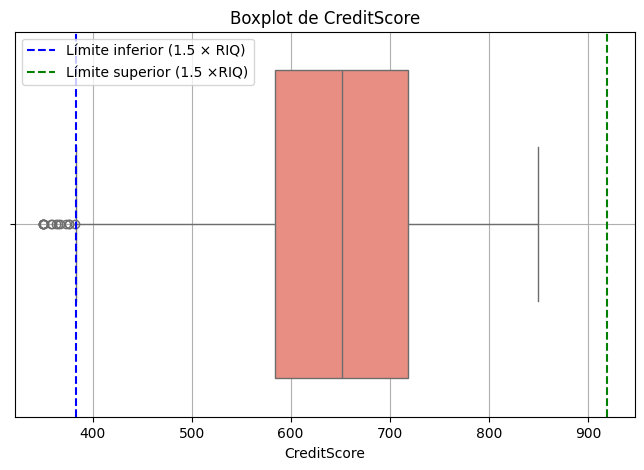

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns


# Seleccionar y limpiar la variable Noise atPlace
noise_data = df['CreditScore'].dropna()

# Calcular cuartiles y RIQ
Q1 = np.percentile(noise_data, 25)
Q2 = np.percentile(noise_data, 50)  # Mediana
Q3 = np.percentile(noise_data, 75)
RIQ = Q3 - Q1

# Calcular límites según la regla 1.5 × RIQ
# Podemos cambiar el multiplicados, sustituyendo el 1.5 por 3
mult = 1.5
limite_inferior = Q1 - mult * RIQ
limite_superior = Q3 + mult * RIQ

# Identificar outliers
outliers = noise_data[(noise_data < limite_inferior) | (noise_data > limite_superior)]

# Mostrar resumen por consola
print("Cuartiles y RIQ:")
print(f"- Q1 (25%): {Q1}")
print(f"- Mediana (Q2): {Q2}")
print(f"- Q3 (75%): {Q3}")
print(f"- Rango Intercuartílico (RIQ): {RIQ}")
print(f"- Límite inferior: {limite_inferior}")
print(f"- Límite superior: {limite_superior}\n")

print("Ejemplos de valores atípicos (primeros 10):")
print(outliers.values[:10])

# Graficar boxplot y añadir líneas con los límites manuales
plt.figure(figsize=(8, 5))
sns.boxplot(x=noise_data, orient='h', color='salmon')

# Agregar líneas verticales para los límites calculados manualmente

plt.axvline(limite_inferior, color='blue', linestyle='--', label=f'Límite inferior ({mult} × RIQ)')
plt.axvline(limite_superior, color='green', linestyle='--', label=f'Límite superior ({mult} ×RIQ)')

plt.title('Boxplot de CreditScore')
plt.xlabel('CreditScore')
plt.legend()
plt.grid(True)
plt.show()


### ***Análisis de distribuciones***

In [ ]:
# Mientras hacemos un análisis univariado de variables numéricas, queremos estudiar su tendencia central y dispersión.

def histogram_boxplot(data, feature, figsize=(12, 7), kde=True, bins=None, mult=1.5):
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize)

    # Calcula percentiles y límites basados en el RIQ
    q1 = data[feature].quantile(0.25)
    q3 = data[feature].quantile(0.75)
    iqr = q3 - q1
    mult = 1.5
    lower_bound = q1 - mult * iqr
    upper_bound = q3 + mult * iqr

    # Boxplot
    sns.boxplot(data=data, x=feature, ax=ax_box2, showmeans=True, color="blue")

    # Histograma
    if bins:
        sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="spring")
    else:
        sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2)

    # Líneas verticales para media, mediana y límites
    ax_hist2.axvline(data[feature].mean(), color="green", linestyle="--", label="Media")
    ax_hist2.axvline(data[feature].median(), color="black", linestyle="-", label="Mediana")
    ax_hist2.axvline(lower_bound, color='blue', linestyle='--', label=f'Límite inferior ({mult}×RIQ)')
    ax_hist2.axvline(upper_bound, color='red', linestyle='--', label=f'Límite superior ({mult}×RIQ)')

    ax_hist2.legend()
    plt.tight_layout()
    plt.show()

Diagrama para RowNumber


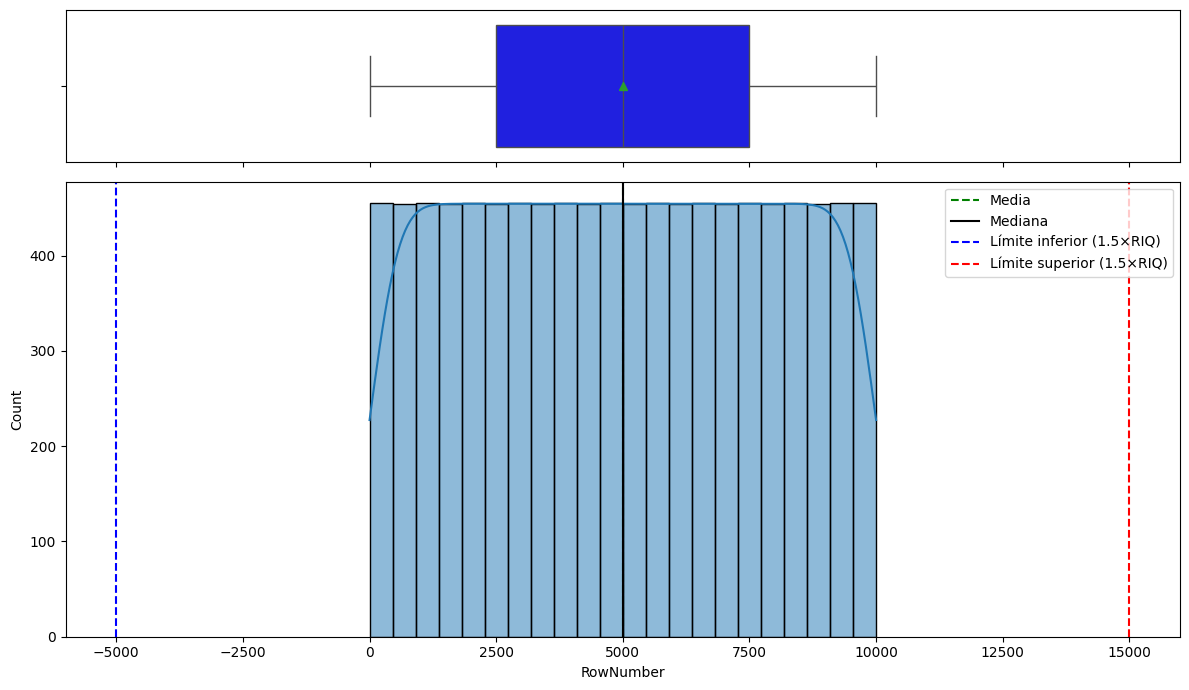

Diagrama para CustomerId


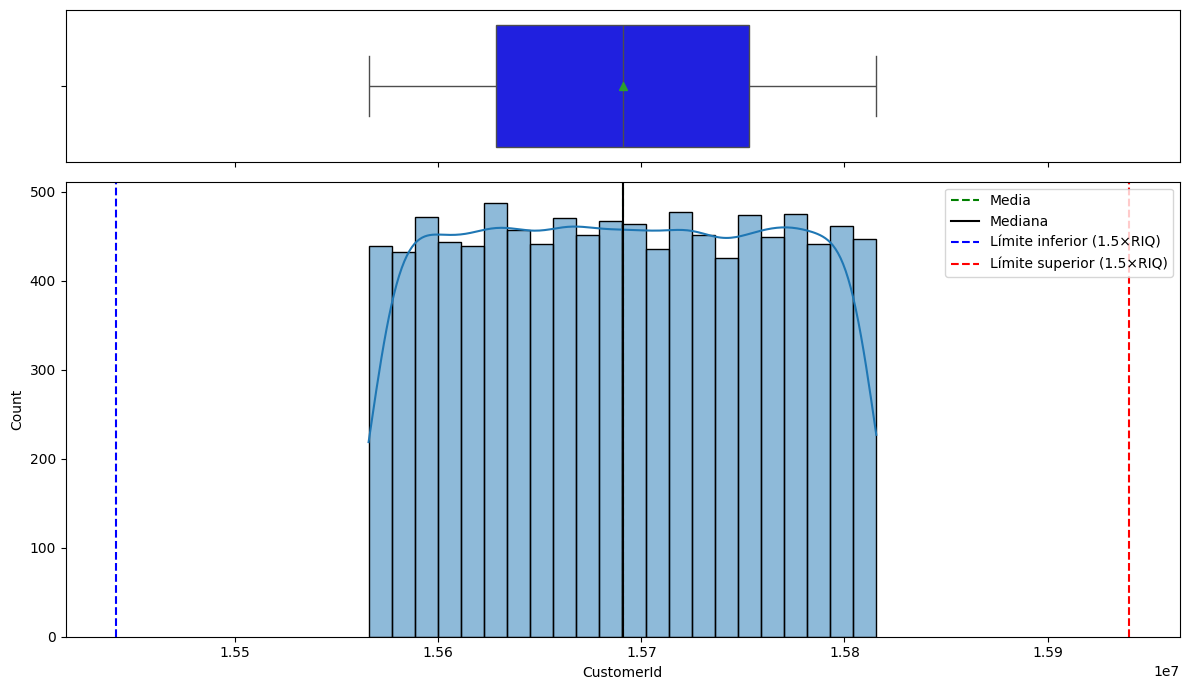

Diagrama para CreditScore


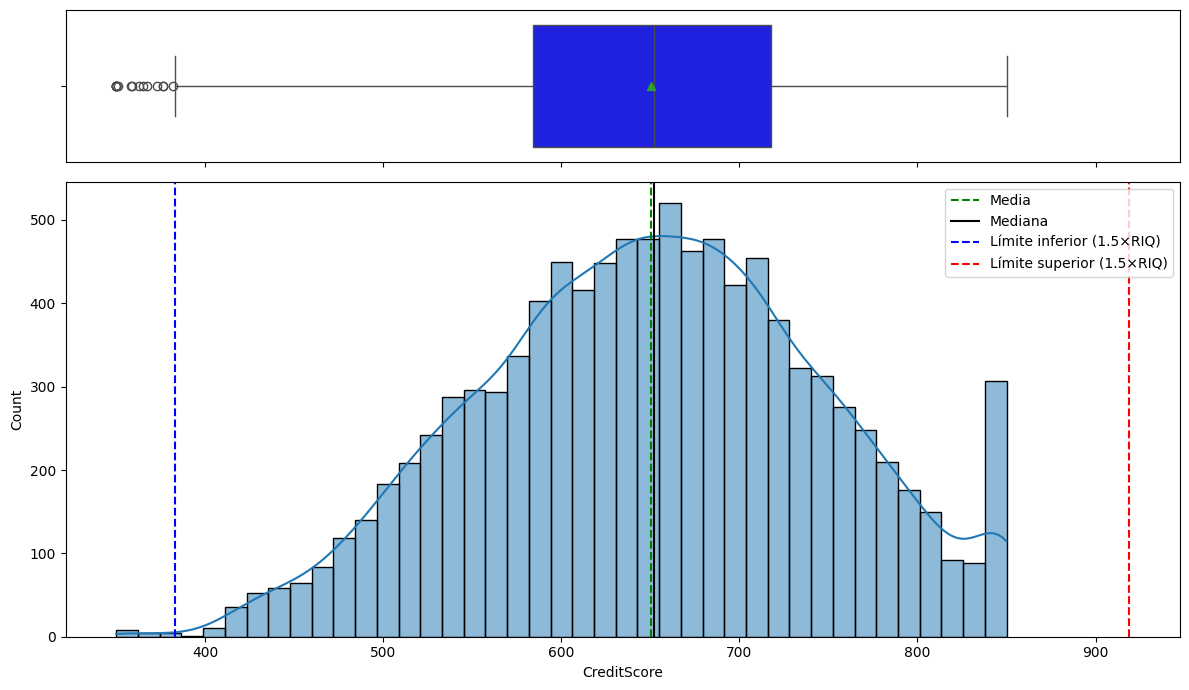

Diagrama para Age


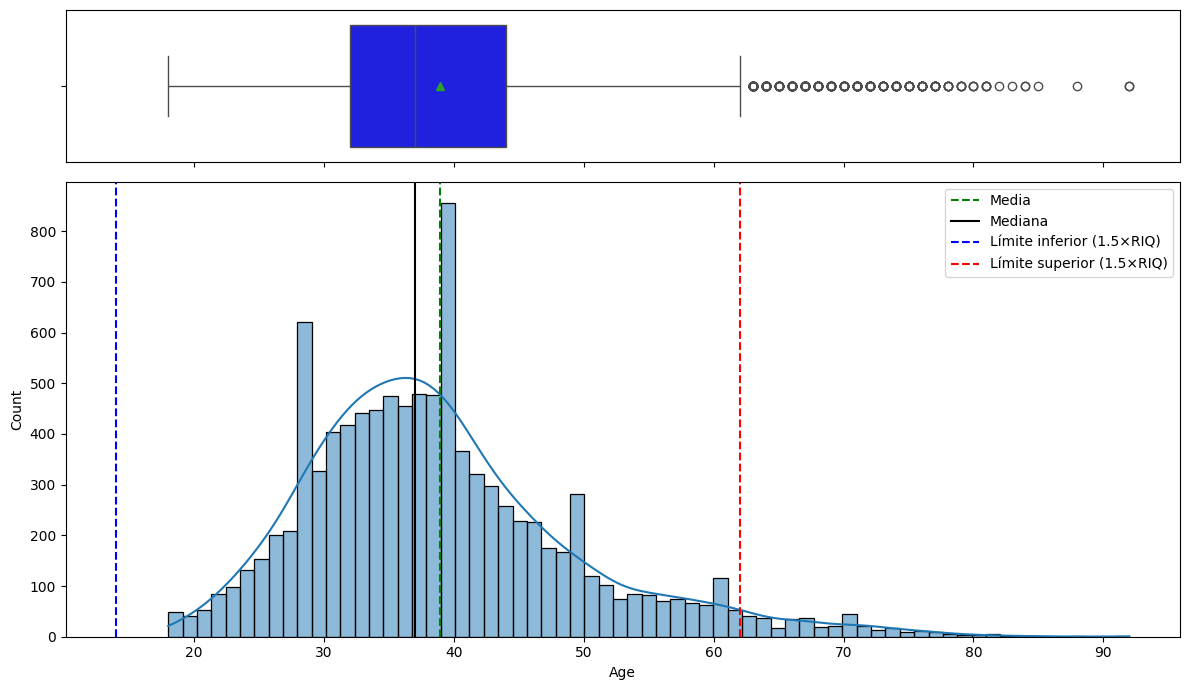

Diagrama para Tenure


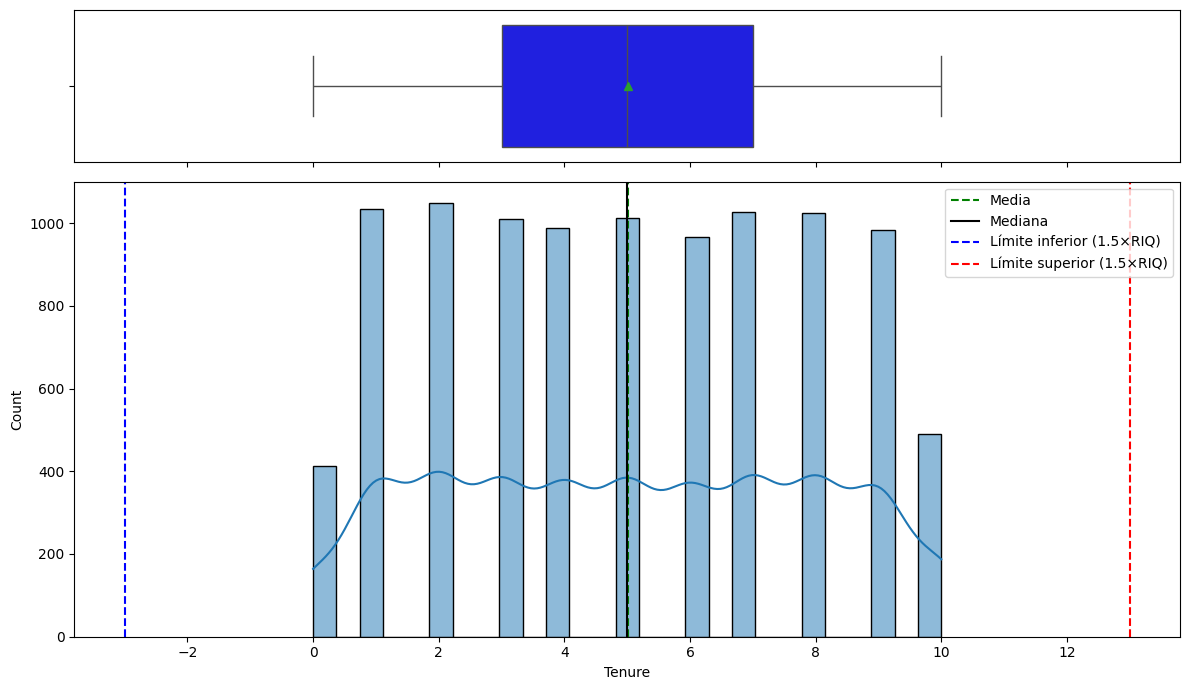

Diagrama para Balance


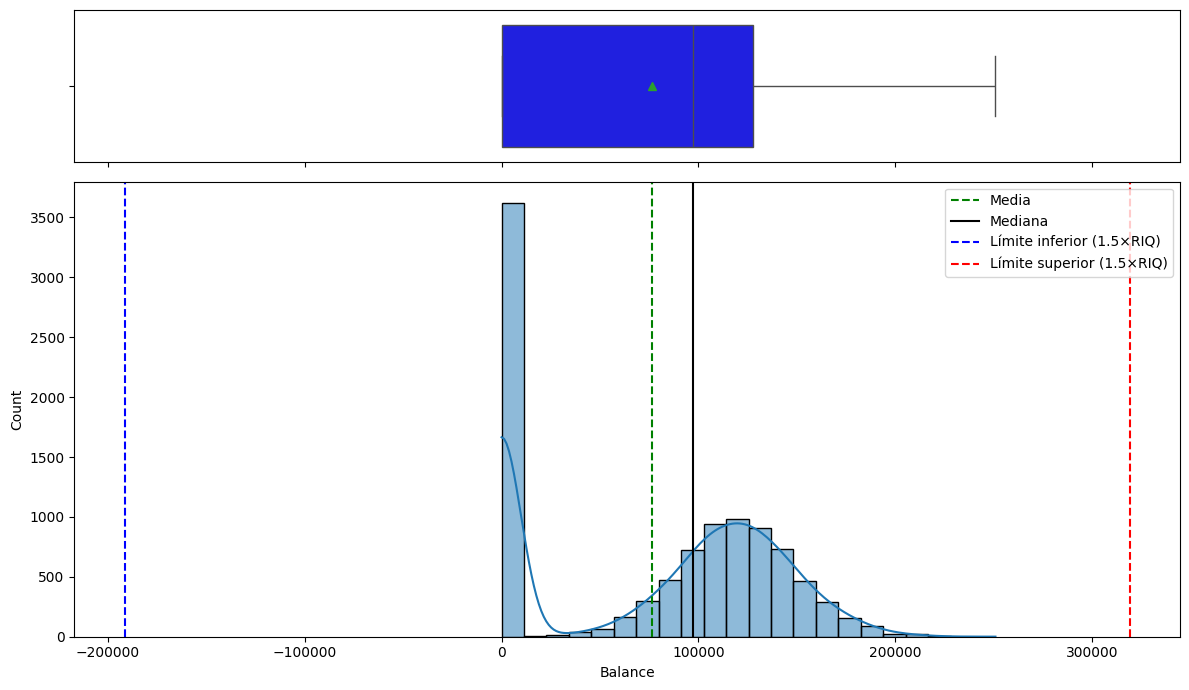

Diagrama para NumOfProducts


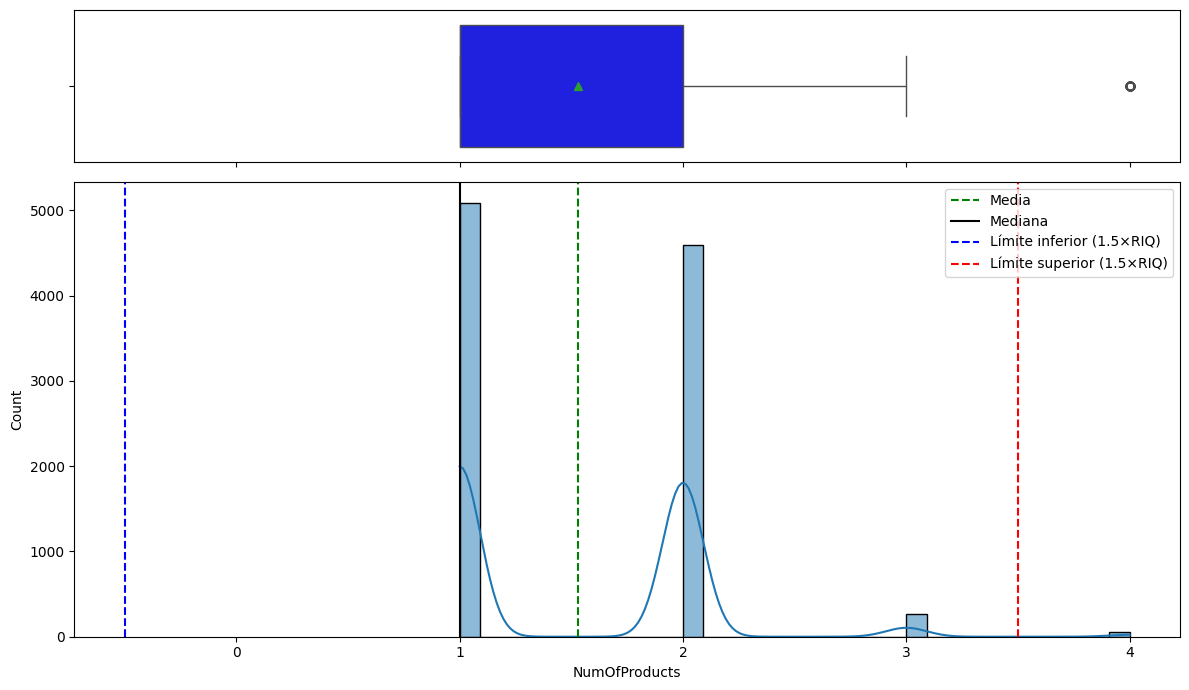

Diagrama para HasCrCard


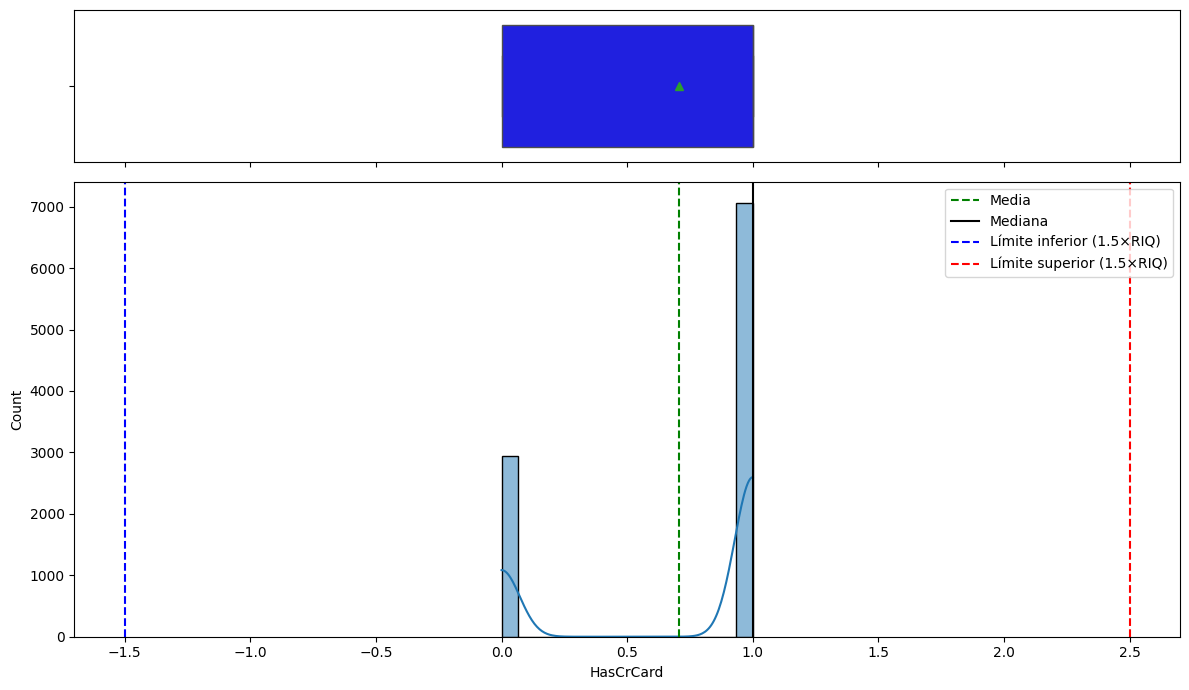

Diagrama para IsActiveMember


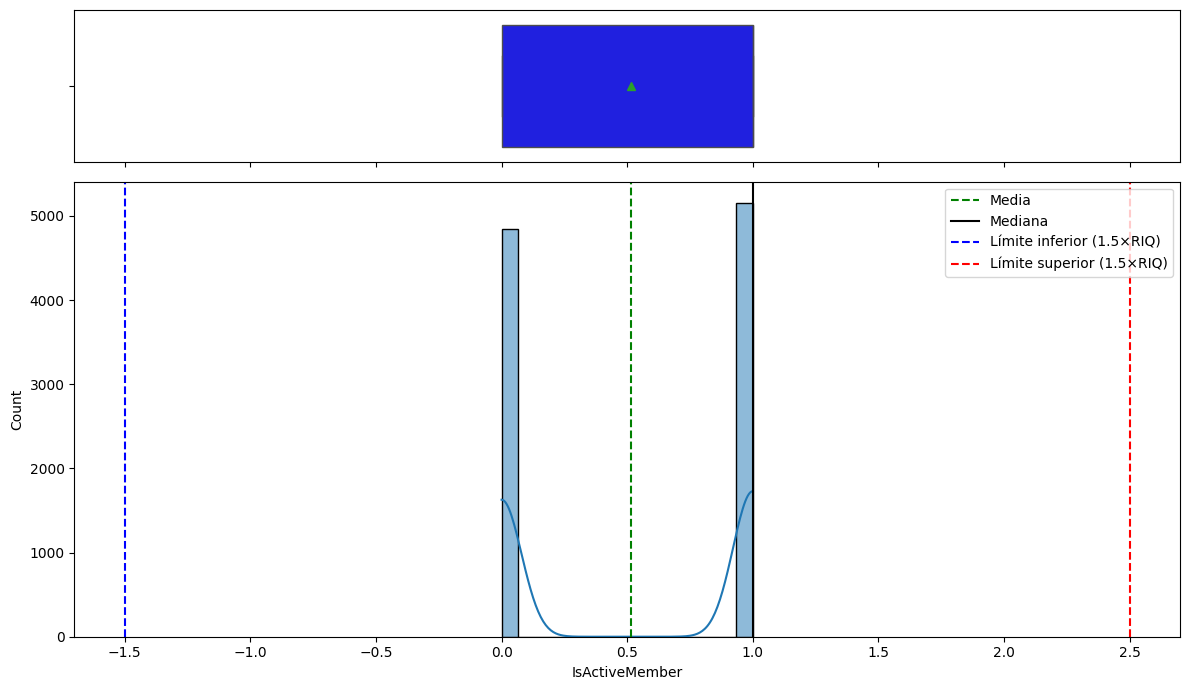

Diagrama para EstimatedSalary


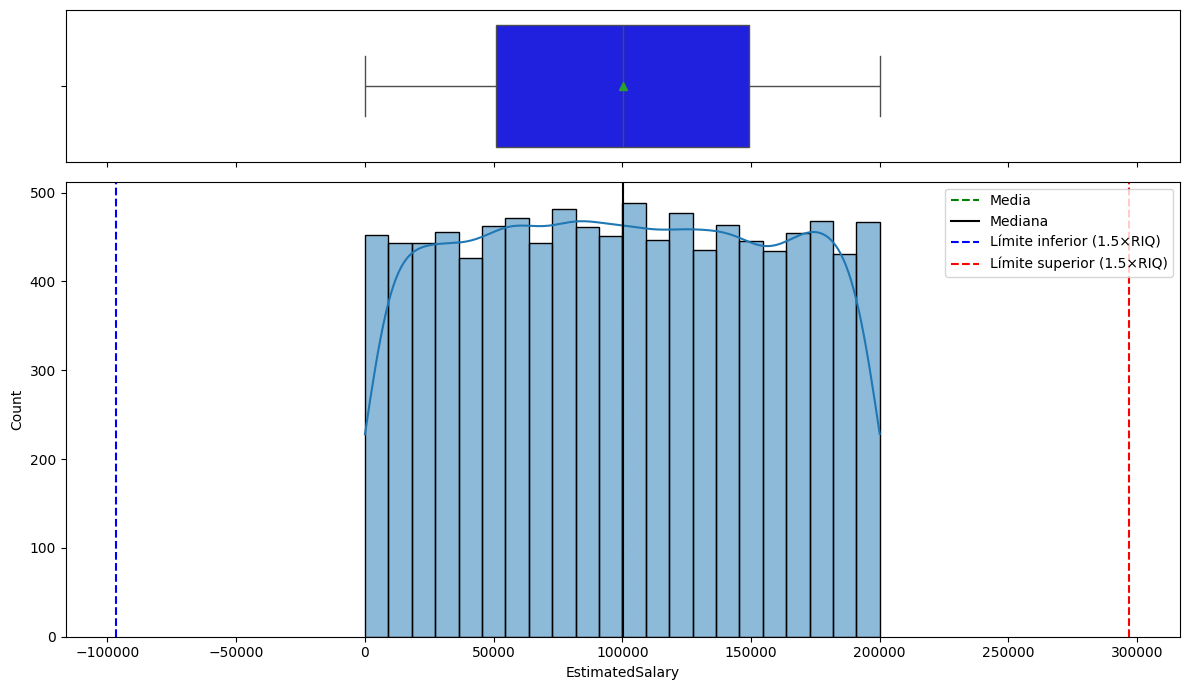

Diagrama para Exited


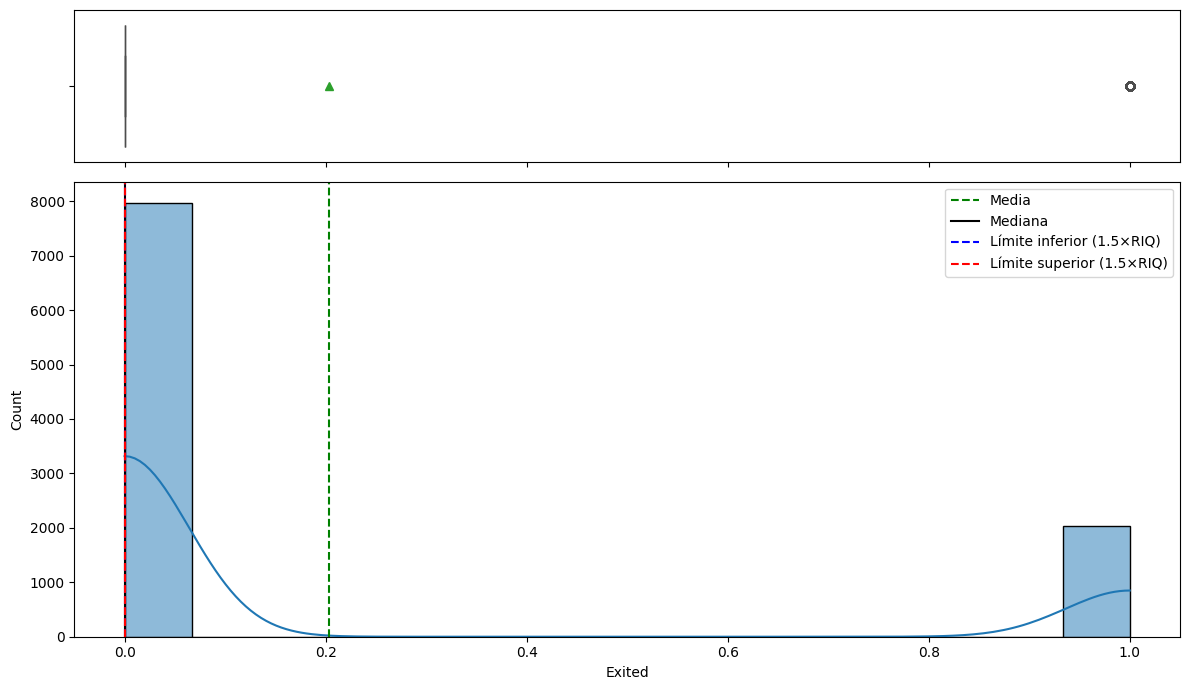

In [ ]:
# Apliquemos la función a las variables numéricas
# Seleccionando todas las columnas numéricas
numeric_columns = df.select_dtypes(include=[np.number]).columns

plt.close('all')
# Aplicar la función a todas las columnas numéricas
for col in numeric_columns:
    print(f"Diagrama para {col}")
    histogram_boxplot(df, col)

Observaciones interesantes sobre las variables:

Tras excluir las variables de identificación (RowNumber, CustomerId), se identificaron los siguientes hallazgos estadísticos:

*   CreditScore: El 50% de las cuentas se concentran en un rango de 600 a 720 puntos. Aplicando la regla del Rango Intercuartílico ($1.5 \times \text{RIC}$), no se observan valores atípicos superiores; sin embargo, existen outliers significativos en el extremo inferior. La mediana se sitúa en 650, representando el perfil típico del cliente.

*   Age: La distribución presenta un marcado sesgo a la derecha (cola larga hacia edades avanzadas). Debido a que la mayoría de los usuarios son menores de 60 años, aquellos que superan este umbral son representados como valores atípicos en el BoxPlot.

*   Balance: Se observa una fuerte concentración (más de 3,000 usuarios) con un saldo de 0. Más que una inconsistencia en el dataset, esto sugiere una "inflación de ceros" inherente al negocio, donde una parte considerable de la cartera no mantiene fondos activos en su cuenta.





### **Resumen estadístico para las variables numéricas**

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


Ahora hacemos una matriz de correlación, con el obejtivo de detectar redundacia entre las variables del dataset. Si detectamos que dos variables estan altamente correlacionadas dejaremos fuera 1 del modelo.

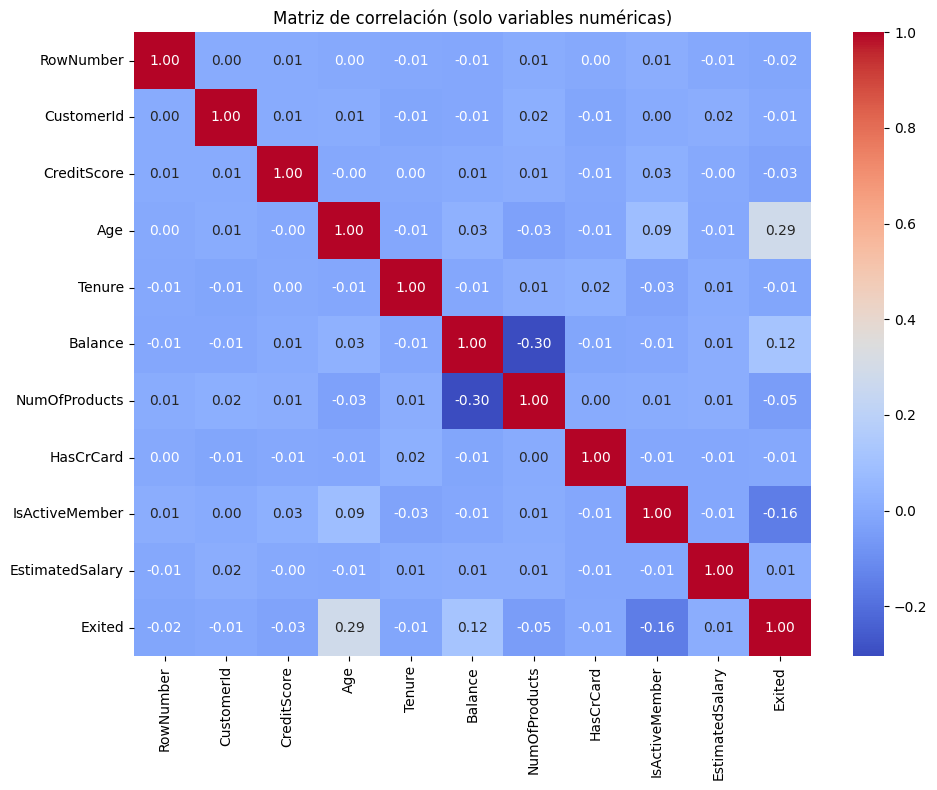

In [ ]:
df_numericas = df.select_dtypes(include=['number'])

# Calcular la matriz de correlación
matriz_corr = df_numericas.corr()

# Graficar la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de correlación (solo variables numéricas)')
plt.tight_layout()
plt.show()

En el caso anterior, no se observó ninguna variable altamente correlacionada
entre si, por lo tanto procedemos a elaborar la arquitectura del modelo de clasificación usando una red neuronal.

### **Análisis de frecuencias de variables categóricas**

In [ ]:
# Creando una lista de variables categóricas
cat_cols =  ['Gender']

# Visualizando los valores únicos
for column in cat_cols:
    print(df[column].value_counts())
    print("_" * 90)

Gender
Male      5457
Female    4543
Name: count, dtype: int64
__________________________________________________________________________________________


**RED NEURONAL**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation

**Preparación de datos**

In [ ]:
# Eliminando columnas
df_encoded = df.drop(['RowNumber', 'CustomerId',"Surname", "Geography", "Gender"], axis=1)
df_encoded.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,42,2,0.00,1,1,1,101348.88,1
1,608,41,1,83807.86,1,0,1,112542.58,0
2,502,42,8,159660.80,3,1,0,113931.57,1
3,699,39,1,0.00,2,0,0,93826.63,0
4,850,43,2,125510.82,1,1,1,79084.10,0


### **Encoding de variables categóricas**
Apliquemos el one hot encoding a las variables categóricas.

In [ ]:
# Creando una lista de variables categóricas
#cat_cols = ['Gender']

# Realizando One Hot Encoding en las columnas categóricas
#df_encoded = pd.get_dummies(df_encoded, columns=cat_cols, drop_first=False)

# Convirtierndo las nuevas columnas a tipo int en logar de booleanos
#for col in df_encoded.columns:
   # if col.startswith(tuple(cat_cols)):
        #df_encoded[col] = df_encoded[col].astype(int)

In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Age              10000 non-null  int64  
 2   Tenure           10000 non-null  int64  
 3   Balance          10000 non-null  float64
 4   NumOfProducts    10000 non-null  int64  
 5   HasCrCard        10000 non-null  int64  
 6   IsActiveMember   10000 non-null  int64  
 7   EstimatedSalary  10000 non-null  float64
 8   Exited           10000 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 703.3 KB


In [ ]:
df_encoded.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,42,2,0.00,1,1,1,101348.88,1
1,608,41,1,83807.86,1,0,1,112542.58,0
2,502,42,8,159660.80,3,1,0,113931.57,1
3,699,39,1,0.00,2,0,0,93826.63,0
4,850,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
features = df_encoded.drop(['Exited'], axis=1)

target = df_encoded['Exited']

In [ ]:
# Splitting the dataset into train and test data
X_train, X_test, y_train, y_test =  train_test_split(features, target, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# Here, we are passing all the features (numerical and categorical), that's okay as min-max scaler will not change values of categorical variables
X_train_normalized = scaler.fit_transform(X_train)

In [ ]:
X_test_normalized = scaler.transform(X_test)

**Usaremos KERAS para obtener hiperaparametros optimos en nuestra Red Neuronal**

In [ ]:
!pip install keras-tuner --upgrade --quiet

In [ ]:
import keras_tuner as kt

In [ ]:
from tensorflow import keras

In [ ]:
def build_model(hp):
    model = keras.Sequential()

    model.add(keras.layers.Input(shape=(X_train_normalized.shape[1],)))

    for i in range(hp.Int('num_layers', 2, 4)):
        model.add(keras.layers.Dense(
            hp.Choice(f'units_{i}', [8, 16, 32, 64]),
            activation='relu'))
        model.add(keras.layers.Dropout(0.2))

    #Activación sigmoide para la probabilidad binaria
    model.add(keras.layers.Dense(1, activation='sigmoid'))

    opt = hp.Choice('optimizer', ['adam', 'rmsprop', 'adagrad'])

    # Compilamos con métricas de negocio
    model.compile(optimizer=opt,
                  loss='binary_crossentropy',
                  metrics=[keras.metrics.AUC(name='auc'), 'accuracy'])
    return model

In [ ]:
# 4. Configuración del Tuner optimizando el AUC
tuner = kt.RandomSearch(
    build_model,
    objective=kt.Objective("val_auc", direction="max"), # Buscamos maximizar el AUC de validación
    max_trials=20,
    directory='tuning_dir',
    project_name='Proyecto_integrador_1_AI_Final_v3'
)

In [ ]:
#Early Stopping para evitar overfitting y ahorrar cómputo
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=10, # Si en 10 épocas no mejora el AUC, se detiene
    restore_best_weights=True
)

In [ ]:
# 5. Ejecución de la Búsqueda
print("Iniciando sintonización de hiperparámetros...")
tuner.search(X_train_normalized, y_train.to_numpy(),
             epochs=100,
             validation_split=0.2,
             batch_size=32,
             callbacks=[early_stop])

Trial 20 Complete [00h 00m 38s]
val_auc: 0.8436610102653503

Best val_auc So Far: 0.8479220867156982
Total elapsed time: 00h 22m 41s


In [ ]:
# 6. Extracción de Resultados
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\n--- Mejores hiperparámetros encontrados ---")
print(f"Optimizador: {best_hps.get('optimizer')}")
print(f"Número de capas ocultas: {best_hps.get('num_layers')}")
for i in range(best_hps.get('num_layers')):
    print(f" - Neuronas en la capa {i+1}: {best_hps.get(f'units_{i}')}")


--- Mejores hiperparámetros encontrados ---
Optimizador: rmsprop
Número de capas ocultas: 2
 - Neuronas en la capa 1: 64
 - Neuronas en la capa 2: 8


In [ ]:
best_model = tuner.hypermodel.build(best_hps)
print("\nResumen del mejor modelo:")
best_model.summary()


Resumen del mejor modelo:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,105 (4.32 KB)

 Trainable params: 1,105 (4.32 KB)

 Non-trainable params: 0 (0.00 B)

## **Entrenemos ahora el modelo óptimo**

In [ ]:
import tensorflow as tf
print(tf.__version__)
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense, Input, InputLayer
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')
import numpy as np

from tensorflow.keras import backend
backend.clear_session()

np.random.seed(42)
tf.random.set_seed(42)

model_opt = tf.keras.Sequential()
model_opt.add(InputLayer(input_shape=(8,)))
model_opt.add(Dense(64, activation = 'relu'))
model_opt.add(Dense(8, activation = 'relu'))
model_opt.add(keras.layers.Dense(1, activation='sigmoid'))

model_opt.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adagrad(learning_rate=0.001),metrics=[keras.metrics.AUC(name='auc'), 'accuracy'])


history1 = model_opt.fit(X_train, y_train, epochs=100, verbose=2, validation_split=0.2)

2.19.0
Epoch 1/100
200/200 - 3s - 17ms/step - accuracy: 0.6908 - auc: 0.5054 - loss: 567.1683 - val_accuracy: 0.6931 - val_auc: 0.4975 - val_loss: 332.5618
Epoch 2/100
200/200 - 1s - 3ms/step - accuracy: 0.6959 - auc: 0.5086 - loss: 243.1141 - val_accuracy: 0.7375 - val_auc: 0.5241 - val_loss: 214.0267
Epoch 3/100
200/200 - 1s - 3ms/step - accuracy: 0.6948 - auc: 0.5045 - loss: 163.6552 - val_accuracy: 0.6819 - val_auc: 0.5259 - val_loss: 147.6901
Epoch 4/100
200/200 - 1s - 3ms/step - accuracy: 0.6977 - auc: 0.5098 - loss: 113.9882 - val_accuracy: 0.6481 - val_auc: 0.5330 - val_loss: 103.1602
Epoch 5/100
200/200 - 1s - 3ms/step - accuracy: 0.7014 - auc: 0.5171 - loss: 74.9837 - val_accuracy: 0.6388 - val_auc: 0.5351 - val_loss: 69.8368
Epoch 6/100
200/200 - 1s - 3ms/step - accuracy: 0.7034 - auc: 0.5190 - loss: 54.5991 - val_accuracy: 0.6144 - val_auc: 0.5461 - val_loss: 58.5178
Epoch 7/100
200/200 - 1s - 3ms/step - accuracy: 0.6992 - auc: 0.5135 - loss: 48.3499 - val_accuracy: 0.5881 

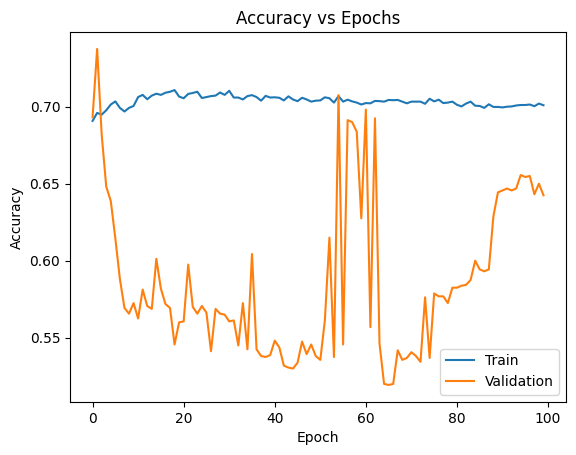

In [ ]:
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.title('Accuracy vs Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()

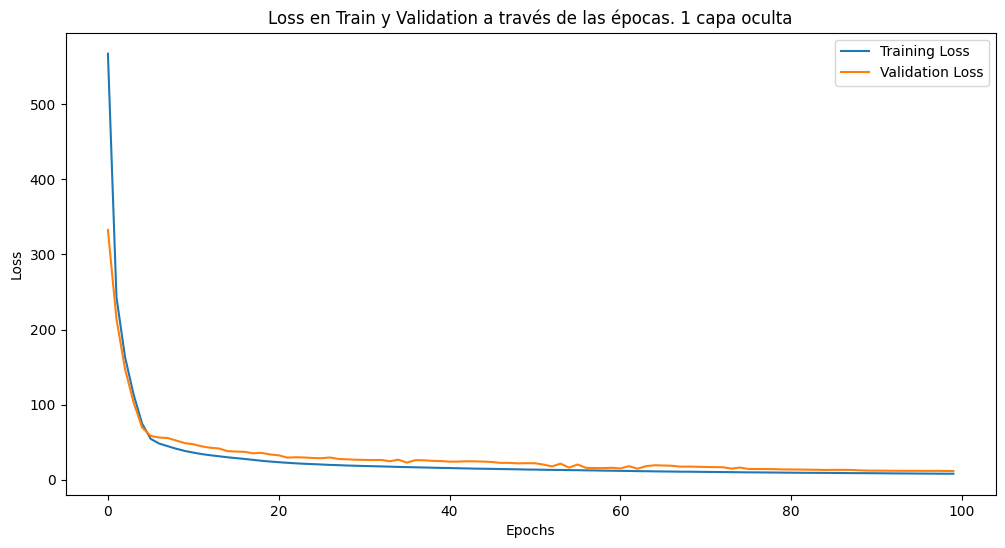

In [ ]:
# Graficando el comp de la función de pérdida
plt.figure(figsize=(12, 6))
plt.plot(history1.history['loss'], label='Training Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')
plt.title('Loss en Train y Validation a través de las épocas. 1 capa oculta')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()



Basado en el grafico donde vemos el desempeño del accuracy, se procede a entrenar el modelo por 200 epocas, con la finalidad de validar si existe convergencia.

In [ ]:
import tensorflow as tf
print(tf.__version__)
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense, Input, InputLayer
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')
import numpy as np

from tensorflow.keras import backend
backend.clear_session()

np.random.seed(42)
tf.random.set_seed(42)

model_opt = tf.keras.Sequential()
model_opt.add(InputLayer(input_shape=(8,)))
model_opt.add(Dense(64, activation = 'relu'))
model_opt.add(Dense(8, activation = 'relu'))
model_opt.add(keras.layers.Dense(1, activation='sigmoid'))

model_opt.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adagrad(learning_rate=0.001),metrics=[keras.metrics.AUC(name='auc'), 'accuracy'])


history2 = model_opt.fit(X_train, y_train, epochs=200, verbose=2, validation_split=0.2)

2.19.0
Epoch 1/200
200/200 - 3s - 13ms/step - accuracy: 0.6823 - auc: 0.5118 - loss: 146.4763 - val_accuracy: 0.6606 - val_auc: 0.5411 - val_loss: 72.9255
Epoch 2/200
200/200 - 1s - 3ms/step - accuracy: 0.6956 - auc: 0.5151 - loss: 68.3016 - val_accuracy: 0.7275 - val_auc: 0.5249 - val_loss: 57.7783
Epoch 3/200
200/200 - 1s - 3ms/step - accuracy: 0.6978 - auc: 0.5183 - loss: 57.9428 - val_accuracy: 0.7431 - val_auc: 0.5187 - val_loss: 53.0652
Epoch 4/200
200/200 - 1s - 3ms/step - accuracy: 0.6933 - auc: 0.5107 - loss: 52.4045 - val_accuracy: 0.7312 - val_auc: 0.5170 - val_loss: 48.8603
Epoch 5/200
200/200 - 1s - 7ms/step - accuracy: 0.6930 - auc: 0.5071 - loss: 48.7960 - val_accuracy: 0.7094 - val_auc: 0.5210 - val_loss: 45.3316
Epoch 6/200
200/200 - 1s - 4ms/step - accuracy: 0.6964 - auc: 0.5119 - loss: 45.6728 - val_accuracy: 0.7219 - val_auc: 0.5334 - val_loss: 43.1136
Epoch 7/200
200/200 - 1s - 3ms/step - accuracy: 0.6933 - auc: 0.5094 - loss: 42.9418 - val_accuracy: 0.7294 - val_a

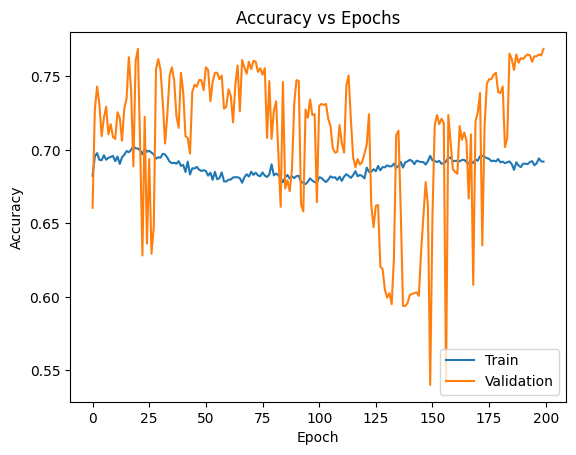

In [ ]:
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.title('Accuracy vs Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()

Se identificó una inconsistencia en el flujo de datos: se utilizó el conjunto X_train sin escalar para el entrenamiento del modelo final, omitiendo la variable X_train_normalized. Este factor impide la convergencia óptima del algoritmo, por lo que se ajustará el proceso para asegurar la integridad de los resultados.

In [ ]:
from tensorflow.keras import backend as K
import matplotlib.pyplot as plt

K.clear_session()

# 1. Recuperamos los mejores hiperparámetros y construimos el modelo óptimo
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
final_model = tuner.hypermodel.build(best_hps)




Entrenando el modelo final con los mejores hiperparámetros...


In [ ]:
# 2. Entrenamos usando LOS DATOS NORMALIZADOS y añadimos el Early Stopping
history_final = final_model.fit(
    X_train_normalized, # ¡Dato escalado!
    y_train.to_numpy(),
    epochs=100,
    verbose=2,
    validation_split=0.2,
    callbacks=[early_stop] # Aprovechamos el callback
)

Epoch 1/100
200/200 - 4s - 18ms/step - accuracy: 0.7800 - auc: 0.5693 - loss: 0.5230 - val_accuracy: 0.7987 - val_auc: 0.6949 - val_loss: 0.4696
Epoch 2/100
200/200 - 1s - 3ms/step - accuracy: 0.7933 - auc: 0.6490 - loss: 0.4886 - val_accuracy: 0.8037 - val_auc: 0.7279 - val_loss: 0.4516
Epoch 3/100
200/200 - 1s - 3ms/step - accuracy: 0.7978 - auc: 0.6813 - loss: 0.4741 - val_accuracy: 0.8144 - val_auc: 0.7500 - val_loss: 0.4406
Epoch 4/100
200/200 - 1s - 3ms/step - accuracy: 0.8028 - auc: 0.7089 - loss: 0.4627 - val_accuracy: 0.8200 - val_auc: 0.7633 - val_loss: 0.4330
Epoch 5/100
200/200 - 1s - 3ms/step - accuracy: 0.8086 - auc: 0.7252 - loss: 0.4529 - val_accuracy: 0.8244 - val_auc: 0.7751 - val_loss: 0.4234
Epoch 6/100
200/200 - 1s - 3ms/step - accuracy: 0.8139 - auc: 0.7353 - loss: 0.4462 - val_accuracy: 0.8306 - val_auc: 0.7841 - val_loss: 0.4183
Epoch 7/100
200/200 - 1s - 3ms/step - accuracy: 0.8184 - auc: 0.7474 - loss: 0.4390 - val_accuracy: 0.8331 - val_auc: 0.7928 - val_loss

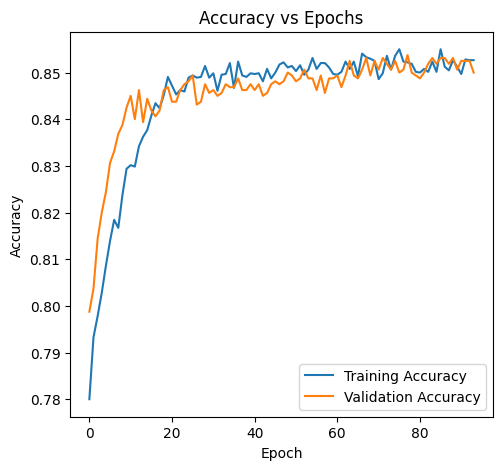

In [ ]:
# 3. Graficando el comportamiento del Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_final.history['accuracy'], label='Training Accuracy')
plt.plot(history_final.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')

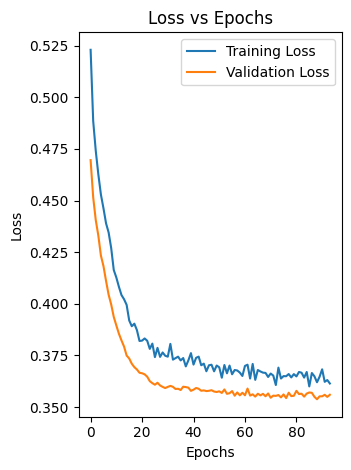

In [ ]:
# 4. Graficando el comportamiento de la función de pérdida
plt.subplot(1, 2, 2)
plt.plot(history_final.history['loss'], label='Training Loss')
plt.plot(history_final.history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
final_model.evaluate(X_test_normalized, y_test.to_numpy(), verbose = 1)
test_pred = np.round(final_model.predict(X_test_normalized))



63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8592 - auc: 0.8372 - loss: 0.3538
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


La precisión del modelo en los datos de prueba resulta ser del 85%, lo que implica que nuestro modelo es capaz de replicar el rendimiento observado en los datos de entrenamiento y validación en los datos de prueba (no vistos).

Ahora calculemos las predicciones y la matriz de confusión:

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


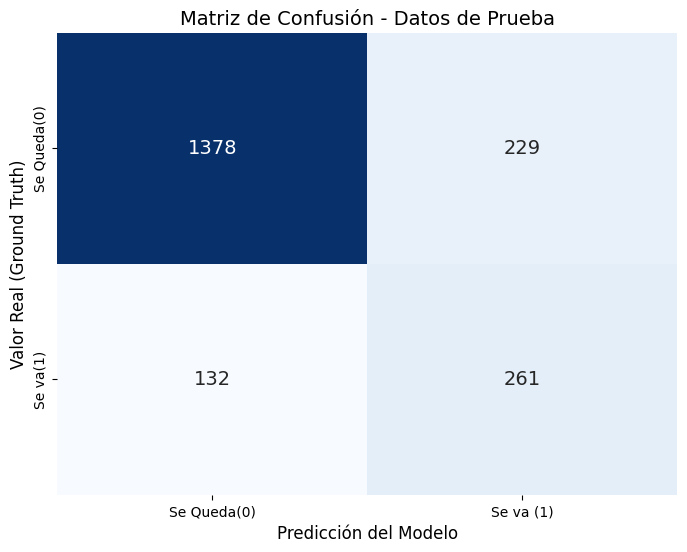


--- 3. Reporte Detallado de Clasificación ---
                    precision    recall  f1-score   support

Clase 0 (Se Queda)       0.91      0.86      0.88      1607
   Clase 1 (Se va)       0.53      0.66      0.59       393

          accuracy                           0.82      2000
         macro avg       0.72      0.76      0.74      2000
      weighted avg       0.84      0.82      0.83      2000



In [ ]:

# ---------------------------------------------------------
# BLOQUE 2: Generación de Predicciones y Matriz de Confusión
# ---------------------------------------------------------
y_pred_prob = final_model.predict(X_test_normalized)

# Convertimos probabilidades a clases absolutas usando un umbral de 0.28
umbral = 0.28
y_pred_clases = (y_pred_prob > umbral).astype("int32")

# Calculamos la matriz de confusión
cm = confusion_matrix(y_test_np, y_pred_clases)

# Visualización ejecutiva
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Se Queda(0)', 'Se va (1)'],
            yticklabels=['Se Queda(0)', 'Se va(1)'],
            annot_kws={"size": 14})
plt.title('Matriz de Confusión - Datos de Prueba', fontsize=14)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Valor Real (Ground Truth)', fontsize=12)
plt.show()

# ---------------------------------------------------------
# BLOQUE 3: Reporte
# ---------------------------------------------------------
print("\n--- 3. Reporte Detallado de Clasificación ---")
print(classification_report(y_test_np, y_pred_clases,
                            target_names=['Clase 0 (Se Queda)', 'Clase 1 (Se va)']))

# Los resultados bajo este nuevo modelo son los siguientes:

Recall  - 66%: El modelo ahora es capaz de identificar a 2 de cada 3 clientes que efectivamente van a abandonar el banco. Este salto del 37% al 66% protege directamente el Customer, permitiendo al banco accionar campañas preventivas sobre una base mucho más amplia de clientes en riesgo real.

Precision - 53%: Al hacer el modelo más sensible, aceptamos estratégicamente un aumento en los Falsos Positivos (clientes leales clasificados como riesgo de fuga). De cada 100 alertas que genere el modelo, 53 serán aciertos y 47 serán falsas alarmas.

ROI: Desde la perspectiva de negocio, el costo de ofrecer un incentivo de retención a un cliente leal (Falso Positivo) es marginal comparado con el altísimo costo de adquirir un cliente nuevo para reemplazar a uno que se fugó en silencio (Falso Negativo). Hemos sacrificado un 3% de Accuracy global (cayendo a 82%) a cambio de capturar casi el doble de la fuga de capitales.

# **Conclusión del Proyecto: Clasificador Basado en Redes Neuronales para la Predicción de Rotación de Clientes Bancarios**

**Antecedentes y Objetivo:**
En la industria de servicios financieros, la retención de clientes es un pilar fundamental para la rentabilidad. El presente proyecto desarrolló un modelo de clasificación binaria basado en Redes Neuronales Profundas con el objetivo de predecir si un cliente bancario abandonará la institución (variable Exited) en los próximos 6 meses. Este modelo predictivo permite a la gerencia identificar los factores de servicio que influyen en la rotación y focalizar proactivamente los esfuerzos de retención. A continuación, se detalla el reporte técnico de la implementación.

**Diagnóstico de Desbalanceo de Clases:**
 Se detectó una asimetría natural en el comportamiento de los clientes: la gran mayoría permanece (Clase 0) y una minoría se fuga (Clase 1). Esto generaba una "ilusión de precisión" global del 85%, pero el modelo original solo lograba detectar el 37% de las fugas reales, lo cual era inaceptable para los objetivos del negocio.

# **Propuesta de Algoritmo/Modelo y Justificación:**
La arquitectura de la red fue optimizada dinámicamente utilizando keras_tuner para encontrar los hiperparámetros ideales, bajo los siguientes criterios:

**Función de Activación y Pérdida:** Se utilizó una activación sigmoid en la capa de salida para obtener una probabilidad de fuga entre 0 y 1. Se optimizó mediante binary_crossentropy, una función que penaliza severamente la "confianza errónea" . Si el modelo asume erróneamente que un cliente de alto valor está seguro en el banco y este se fuga, el error matemático explota, forzando a la red a aprender los patrones de riesgo.

**Métrica de Optimización (AUC):** Se priorizó maximizar el Área Bajo la Curva (AUC) por encima del Accuracy, dado que el AUC evalúa la capacidad del modelo para distinguir entre clientes leales y desertores independientemente del desbalanceo de las clases.

**Ajuste del Umbral de Decisión:** Se redujo el umbral de clasificación de 0.50 a 0.28.  En el contexto bancario, es preferible incluir a un cliente en una campaña de retención por error (Falso Positivo, costo bajo) que permitir que un cliente se vaya a la competencia sin intentar retenerlo (Falso Negativo, costo alto). Este ajuste incrementó el Recall (tasa de detección) del 37% al 66%

In [ ]:
import plotly.offline as pyo
pyo.init_notebook_mode(connected=True)

In [ ]:
!jupyter nbconvert --to html "/content/Proyecto_integrador_1_AI_final.ipynb"

[NbConvertApp] Converting notebook /content/Proyecto_integrador_1_AI_final.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 19 image(s).
[NbConvertApp] Writing 1568893 bytes to /content/Proyecto_integrador_1_AI_final.html
